## Introduction to Housing Price Analysis

This notebook performs an exploratory data analysis and statistical inference on a housing dataset.It covers descriptive statistics, probability distributions, hypothesis testing to compare house prices based on features like air conditioning and preferred area, and finally, explore correlations between numerical features, emphasizing the distinction between correlation and causation.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
Housing = pd.read_csv("/content/Cleaned_Housing.csv")
Housing

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


Descriptive statistics(mean,median,standard deviation and variance)


In [3]:

Hse_mean = Housing[["price", "area", "bedrooms", "bathrooms","stories","parking"]].mean()
Hse_mean


,0
price,4.766729e+06
area,5.150541e+03
bedrooms,2.965138e+00
bathrooms,1.286239e+00
stories,1.805505e+00
parking,6.935780e-01


In [4]:
Hse_median = Housing[["price", "area", "bedrooms", "bathrooms","stories","parking"]].median()
Hse_median

,0
price,4340000.0
area,4600.0
bedrooms,3.0
bathrooms,1.0
stories,2.0
parking,0.0


In [5]:
Hse_std = Housing[["price", "area", "bedrooms", "bathrooms","stories","parking"]].std()
Hse_std

,0
price,1.870440e+06
area,2.170141e+03
bedrooms,7.380639e-01
bathrooms,5.024696e-01
stories,8.674925e-01
parking,8.615858e-01


In [6]:
Hse_var = Housing[["price", "area", "bedrooms", "bathrooms","stories","parking"]].var()
Hse_var

,0
price,3.498544e+12
area,4.709512e+06
bedrooms,5.447383e-01
bathrooms,2.524757e-01
stories,7.525432e-01
parking,7.423300e-01


In [7]:
descriptive_stats = pd.concat([Hse_mean,Hse_median,Hse_std, Hse_var], axis=1)
descriptive_stats.columns = ['mean', 'median', 'std', 'var']
descriptive_stats

,mean,median,std,var
price,4.766729e+06,4340000.0,1.870440e+06,3.498544e+12
area,5.150541e+03,4600.0,2.170141e+03,4.709512e+06
bedrooms,2.965138e+00,3.0,7.380639e-01,5.447383e-01
bathrooms,1.286239e+00,1.0,5.024696e-01,2.524757e-01
stories,1.805505e+00,2.0,8.674925e-01,7.525432e-01
parking,6.935780e-01,0.0,8.615858e-01,7.423300e-01


Summary of Descriptive statistics

Price: The average price is approximately 4.77 million, with a median of 4.34 million, indicating a right-skewed distribution. The standard deviation is about 1.87 million, showing considerable variability in prices.

Area: The average area is around 5150 sq ft, with a median of 4600 sq ft. The standard deviation is 2170 sq ft, suggesting a moderate spread in property sizes.

Bedrooms: On average, properties have about 3 bedrooms (mean ~2.97), with a median of 3 bedrooms. The standard deviation is low (0.74), meaning most properties have a similar number of bedrooms.

Bathrooms: The average number of bathrooms is about 1.29, with a median of 1. The standard deviation is 0.5, indicating that most properties have 1 or 2 bathrooms.

Stories: Properties typically have between 1 and 2 stories (mean ~1.81, median 2). The standard deviation is 0.87.

Parking: The average parking spaces are less than 1 (mean ~0.69), with a median of 0. The standard deviation is 0.86, suggesting a good portion of properties might not have dedicated parking or have only one space

Probability distribution

Price distribution is right-skewed, meaning there's a higher concentration of properties at the lower end of the price spectrum, with fewer properties at very high prices. The mean (approximately 4.77 million) is higher than the median (4.34 million) due to the higher-priced outliers pulling the mean upwards as shown in the plot below.

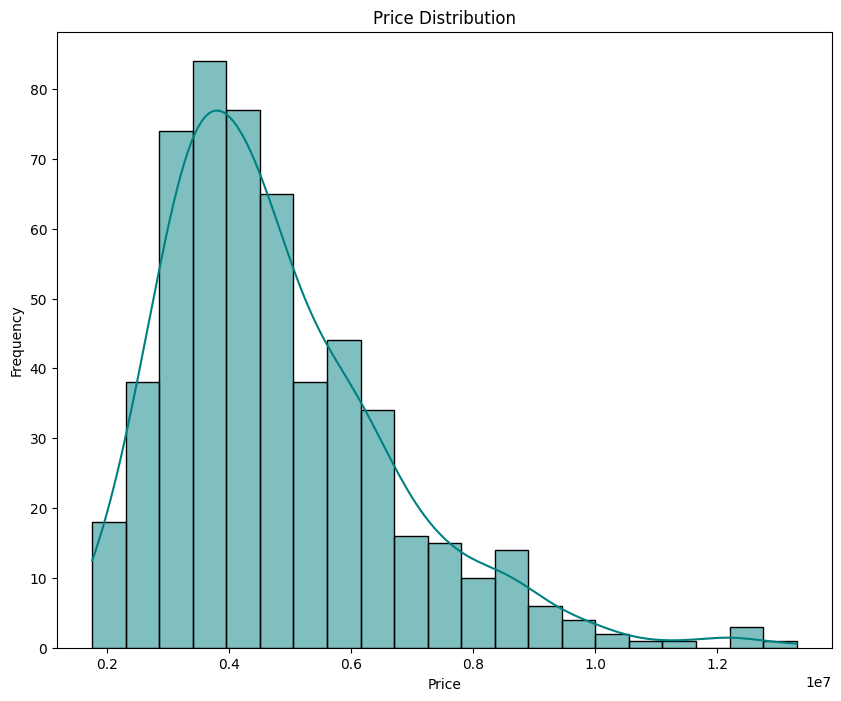

In [8]:
# Price distribution
plt.figure(figsize=(10, 8))
sns.histplot(Housing["price"], color="teal",kde=True)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title("Price Distribution")
plt.show()


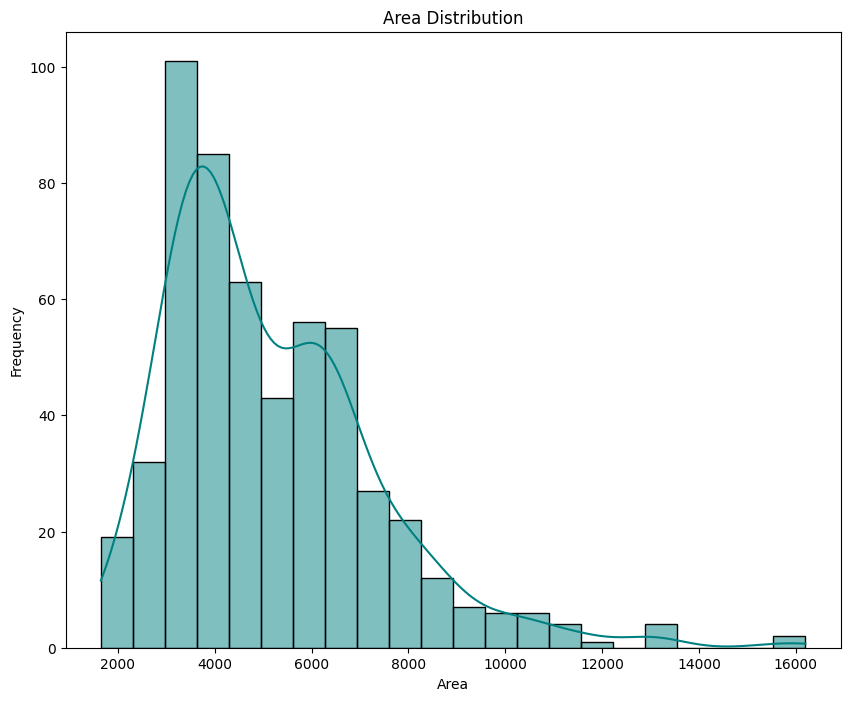

In [9]:
plt.figure(figsize=(10, 8))
sns.histplot(x=Housing["area"], kde=True, color="teal")
plt.xlabel('Area')
plt.ylabel('Frequency')
plt.title("Area Distribution")
plt.show()

The area distribution is right-skewed, indicating a higher frequency of smaller to medium-sized properties. Most properties fall within the 2000 to 6000 sq ft range, with a peak around 4000-5000 sq ft.
This indicates that, there are fewer properties with very large areas. The mean area (5150 sq ft) is slightly higher than the median (4600 sq ft), which is consistent with the distribution being pulled towards larger values by a few outliers as shown in the plot above.

### Probability Density Plots

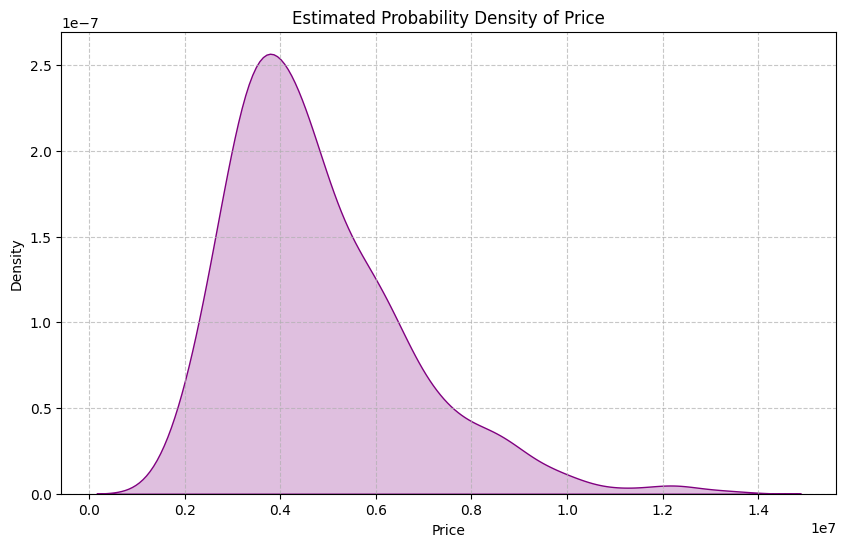

In [10]:
plt.figure(figsize=(10, 6))
sns.kdeplot(Housing['price'], fill=True, color='purple')
plt.title('Estimated Probability Density of Price')
plt.xlabel('Price')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

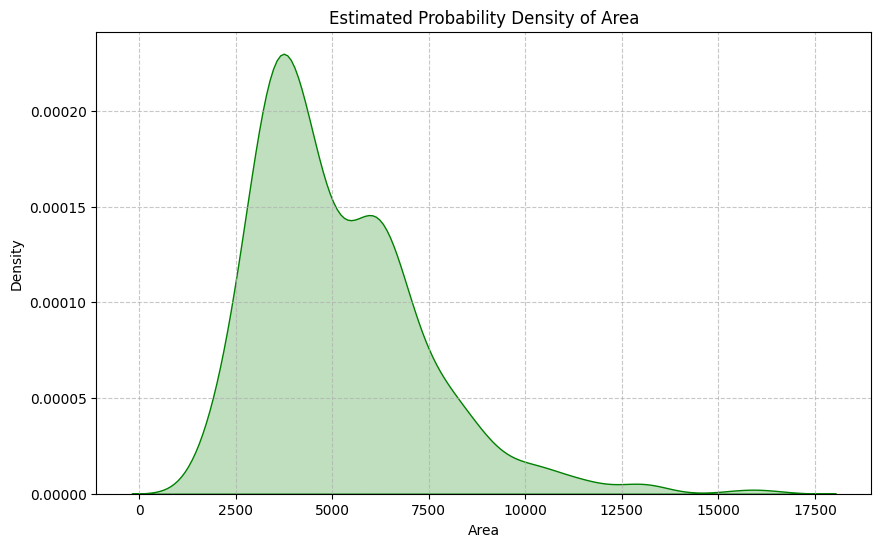

In [11]:
plt.figure(figsize=(10, 6))
sns.kdeplot(Housing['area'], fill=True, color='green')
plt.title('Estimated Probability Density of Area')
plt.xlabel('Area')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

These `kdeplot` visualizations represent the **estimated probability density functions** for 'price' and 'area'. The y-axis ('Density') shows the likelihood of observing a value at a given point, such that the total area under the curve sums to 1.

Hypothesis Testing

### Formulating a Hypothesis

Impact of 'airconditioning' on 'price'.

**Null Hypothesis (H0):** There is no significant difference in the average price of houses with air conditioning and houses without air conditioning.

**Alternative Hypothesis (Ha):** There is a significant difference in the average price of houses with air conditioning and houses without air conditioning.

Mean price for houses with AC: 6013220.5813953485
Mean price for houses without AC: 4191939.678284182

Standard deviation for houses with AC: 1998149.474992723
Standard deviation for houses without AC: 1493711.7609608257


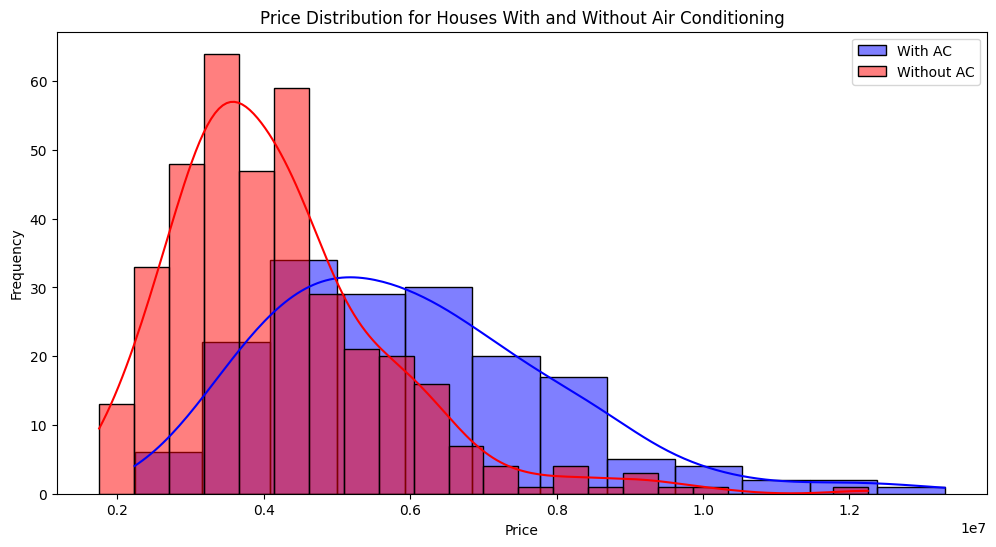

In [13]:
# separate the dataset into two groups based on the 'airconditioning' feature.
houses_with_ac = Housing[Housing['airconditioning'] == 'yes']['price']
houses_without_ac = Housing[Housing['airconditioning'] == 'no']['price']

# Display the basic statistics for each group to get a preliminary idea
print("Mean price for houses with AC:", houses_with_ac.mean())
print("Mean price for houses without AC:", houses_without_ac.mean())
print("\nStandard deviation for houses with AC:", houses_with_ac.std())
print("Standard deviation for houses without AC:", houses_without_ac.std())

# Visualize the distribution of prices for both groups
plt.figure(figsize=(12, 6))
sns.histplot(houses_with_ac, color='blue', label='With AC', kde=True)
sns.histplot(houses_without_ac, color='red', label='Without AC', kde=True)
plt.title('Price Distribution for Houses With and Without Air Conditioning')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Performing a Two-Sample T-Test

To formally test the hypothesis, use a two-sample t-test. This test compares the means of two independent groups to determine if there is a statistically significant difference between them.

**Assumptions for the T-Test:**
1.  **Independence:** The two samples (prices of houses with AC and without AC) are independent. (Met by design)
2.  **Normality:** The data in each group should be approximately normally distributed. (While the distributions are somewhat skewed, the t-test is robust to moderate departures from normality, especially with larger sample sizes)
3.  **Homogeneity of Variances:** The variances of the two groups should be approximately equal.

In [14]:
from scipy import stats

# Perform independent two-sample t-test
# set equal_var=False because the standard deviations (and thus variances) appear to be different from our preliminary analysis.
t_statistic, p_value = stats.ttest_ind(houses_with_ac, houses_without_ac, equal_var=False)

print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value: {p_value:.3e}") # Display p-value in scientific notation for very small values

# Set a significance level (alpha)
alpha = 0.05

# Interpret the results
print(f"\nSignificance level (alpha): {alpha}")
if p_value < alpha:
    print("Since the p-value is less than alpha, we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference in the average price of houses with and without air conditioning.")
else:
    print("Since the p-value is greater than alpha, we fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference in the average price of houses with and without air conditioning.")

T-statistic: 10.659
P-value: 2.804e-22

Significance level (alpha): 0.05
Since the p-value is less than alpha, we reject the null hypothesis.
Conclusion: There is a statistically significant difference in the average price of houses with and without air conditioning.


**Null Hypothesis (H0):** There is no significant difference in the average price of houses in a preferred area and houses not in a preferred area.

**Alternative Hypothesis (Ha):** There is a significant difference in the average price of houses in a preferred area and houses not in a preferred area.

Mean price for houses in preferred area: 5879045.703125
Mean price for houses not in preferred area: 4425298.776978417

Standard deviation for houses in preferred area: 1984004.8642131716
Standard deviation for houses not in preferred area: 1695810.5603415868


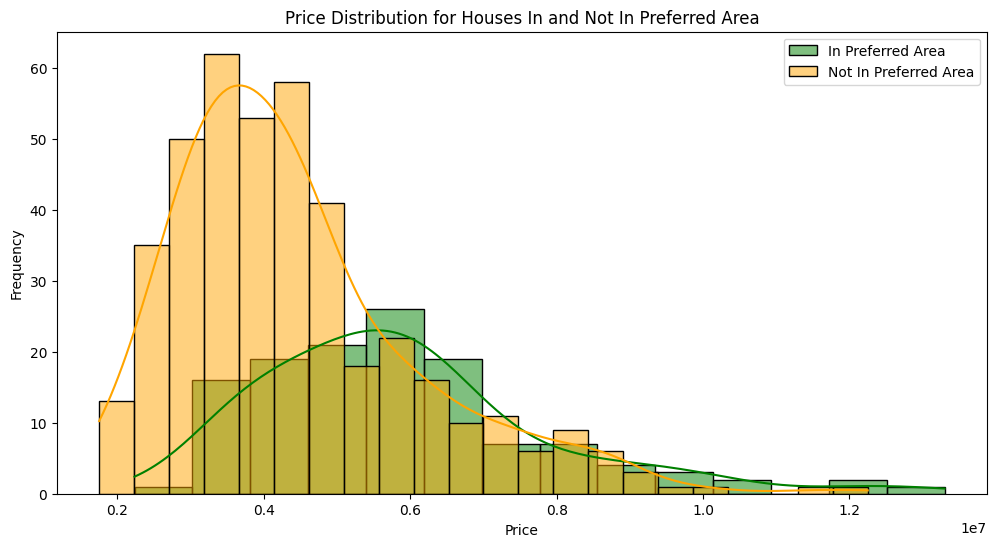

In [15]:
# Separate the dataset into two groups based on the 'prefarea' feature.
houses_in_prefarea = Housing[Housing['prefarea'] == 'yes']['price']
houses_not_in_prefarea = Housing[Housing['prefarea'] == 'no']['price']

# Display the basic statistics for each group
print("Mean price for houses in preferred area:", houses_in_prefarea.mean())
print("Mean price for houses not in preferred area:", houses_not_in_prefarea.mean())
print("\nStandard deviation for houses in preferred area:", houses_in_prefarea.std())
print("Standard deviation for houses not in preferred area:", houses_not_in_prefarea.std())

# Visualize the distribution of prices for both groups
plt.figure(figsize=(12, 6))
sns.histplot(houses_in_prefarea, color='green', label='In Preferred Area', kde=True)
sns.histplot(houses_not_in_prefarea, color='orange', label='Not In Preferred Area', kde=True)
plt.title('Price Distribution for Houses In and Not In Preferred Area')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend()
plt.show()

### Performing a Two-Sample T-Test for 'prefarea'

Similar to the previous test,  use a two-sample t-test to compare the means of prices for houses in preferred areas and those not in preferred areas.

**Assumptions for the T-Test:**
1.  **Independence:** The two samples are independent. (Met)
2.  **Normality:** Data in each group should be approximately normally distributed (t-test is robust for large samples).
3.  **Homogeneity of Variances:** again use `equal_var=False` due to potentially unequal variances, as indicated by the differing standard deviations.

In [16]:
from scipy import stats

# Perform independent two-sample t-test
# We set equal_var=False because the standard deviations appear to be different.
t_statistic_prefarea, p_value_prefarea = stats.ttest_ind(houses_in_prefarea, houses_not_in_prefarea, equal_var=False)

print(f"T-statistic for prefarea: {t_statistic_prefarea:.3f}")
print(f"P-value for prefarea: {p_value_prefarea:.3e}")

# Set a significance level (alpha)
alpha = 0.05

# Interpret the results
print(f"\nSignificance level (alpha): {alpha}")
if p_value_prefarea < alpha:
    print("Since the p-value is less than alpha, we reject the null hypothesis.")
    print("Conclusion: There is a statistically significant difference in the average price of houses in preferred areas and those not in preferred areas.")
else:
    print("Since the p-value is greater than alpha, we fail to reject the null hypothesis.")
    print("Conclusion: There is no statistically significant difference in the average price of houses in preferred areas and those not in preferred areas.")

T-statistic for prefarea: 7.492
P-value for prefarea: 2.592e-12

Significance level (alpha): 0.05
Since the p-value is less than alpha, we reject the null hypothesis.
Conclusion: There is a statistically significant difference in the average price of houses in preferred areas and those not in preferred areas.


In [17]:
# Correlation vs causation

### Correlation vs. Causation

It's important to understand the distinction between correlation and causation in statistical analysis.

*   **Correlation** measures the strength and direction of a linear relationship between two variables. If two variables are correlated, it means they tend to change together (e.g., as one increases, the other also tends to increase, or vice-versa). However, correlation does *not* imply that one variable causes the other.

*   **Causation** means that one event or variable directly leads to another event or variable. Establishing causation is much more complex than establishing correlation and often requires controlled experiments or more advanced statistical techniques.

In this housing dataset, while there might be strong correlations between certain features (like `area` and `price`), it doesn't automatically mean that increasing the area directly *causes* a proportional increase in price without considering other factors. It simply means they move together.

Correlation Matrix:


,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


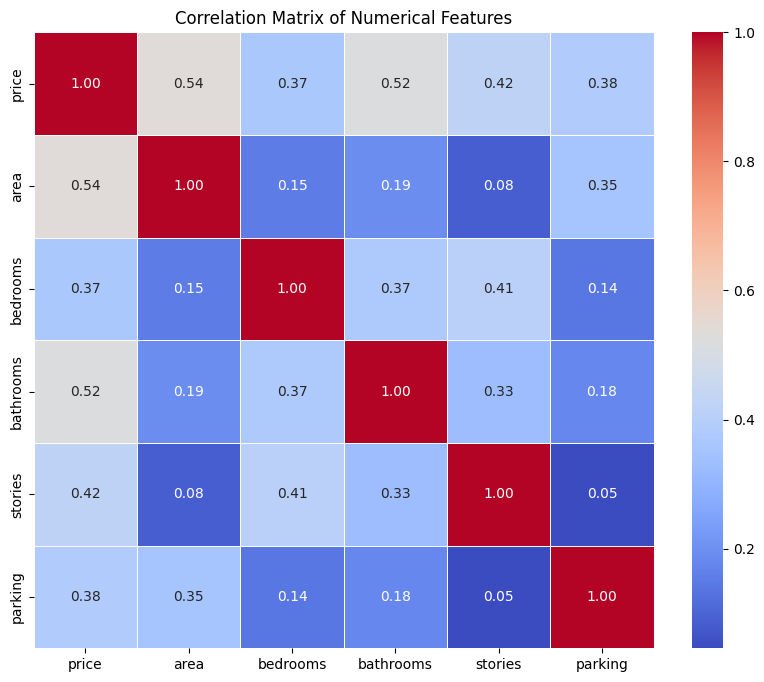

In [18]:
# Select only numerical columns for correlation calculation
numerical_cols = Housing.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = Housing[numerical_cols].corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Visualize the correlation matrix using a heatmap for better readability
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Interpretation
The correlation matrix and heatmap provide valuable insights into the linear relationships between the numerical features in our housing dataset. Here are the key observations:

*   **Strong Positive Correlations with Price:**
    *   `price` and `area`: 0.54
    *   `price` and `bathrooms`: 0.52
    *   `price` and `stories`: 0.42
    *   `price` and `parking`: 0.38
    *   `price` and `bedrooms`: 0.37

These values indicate a **strong positive correlation**, meaning that as one of these features increases (e.g., a larger `area`, more `bathrooms`, or more `stories`), the `price` of the house tends to increase as well. This is intuitive, as larger, more amenity-rich houses typically command higher prices.

*   **Other Notable Correlations:**
    *   `area` also shows moderate positive correlations with `parking` (0.35) and `bathrooms` (0.19).
    *   `bedrooms` has moderate positive correlations with `bathrooms` (0.37) and `stories` (0.41).
